# Trend Convexity

This research notebook documents the methodology, results, and empirical findings presented in the Trend Convexity paper. The primary objective is to develop reproducible code for the paper's analyses while creating a reference for future research on the convexity of trend-following returns. It also serves as a central repository for research related to trend convexity produced by Capital Fund Management.

# Path Management & Files

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from   matplotlib.ticker import FuncFormatter

# Data Prep

In [2]:
index_path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\TrendIndices\TrendIndicesGuide.xlsx"
tickers    = (pd.read_excel(
    io = index_path, sheet_name = "IndexReplication").
    query("group == 'TLDao'").
    ticker.
    drop_duplicates().
    sort_values().
    to_list())

tmp_tickers = [
    ticker.replace(" 1", "1").lower().replace(" ", "_") 
    for ticker in tickers]

path          = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\Signals\DaoNguyenDerembleLemperiereBouchaudPotters.parquet"
df_signal_raw = pd.read_parquet(path = path, engine = "pyarrow").query("ticker == @tmp_tickers")

# Analyzing Hedge Fund and CTA Returns

The analysis begins by examining the relationship between hedge fund returns and equity market returns. Three Bloomberg indices are considered:
1. BARCBTOP — Barclay CTA Index
2. HFRIFWI — Hedge Fund Composite Index
3. NEIXCTA — Société Générale CTA Index

In [3]:
hf_path = r"A:\2026BlpAdHocData\Combined\PX\hf_indices.parquet"
eq_path = r"A:\2026BlpAdHocData\Combined\PX\EquityIndices.parquet"

df_hf = pd.read_parquet(path = hf_path, engine = "pyarrow")

renamer = {
    "BARCBTOP": "Barclay CTA",
    "HFRIFWI" : "Hedge Fund Composite Index",
    "NEIXCTA" : "SocGen CTA Index"}

In [4]:
df_spx = (pd.read_parquet(
    path = eq_path, engine = "pyarrow").
    query("security == 'SPX Index'").
    set_index("date").
    sort_index().
    assign(px_val = lambda x: np.cumprod(1 + (x.RT112 / 100)) * 100)
    [["px_val"]].
    rename(columns = {"px_val": "spx_rebuilt"}))

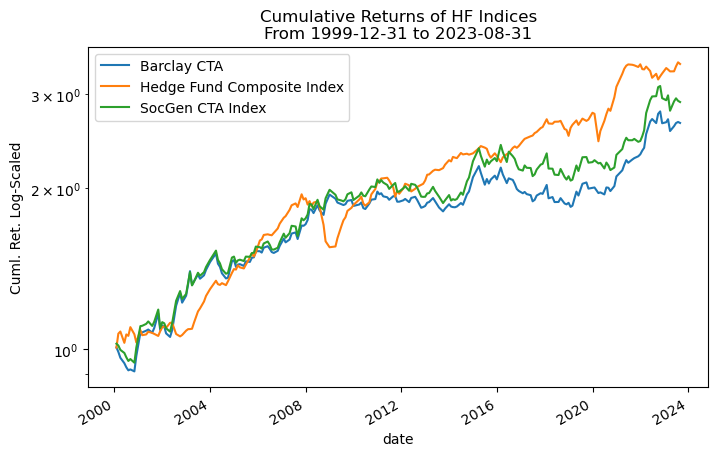

In [5]:
df_plot = (df_hf.assign(
    security = lambda x: x.security.str.split(" ").str[0]).
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "PX_LAST").
    dropna().
    pct_change().
    apply(lambda x: np.cumprod(1 + x)))
    
(df_plot.
    rename(columns = renamer).
    plot(
        figsize = (8,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of HF Indices\nFrom {} to {}".format(
            df_plot.index.min().date(),
            df_plot.index.max().date())))

plt.show()

In [6]:
df_wider = (df_hf.assign(
    security = lambda x: x.security.str.split(" ").str[0]).
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "PX_LAST").
    dropna().
    merge(right = df_spx, how = "inner", on = ["date"]).
    rename(columns = {"spx_rebuilt": "SPX"}).
    pct_change().
    dropna())

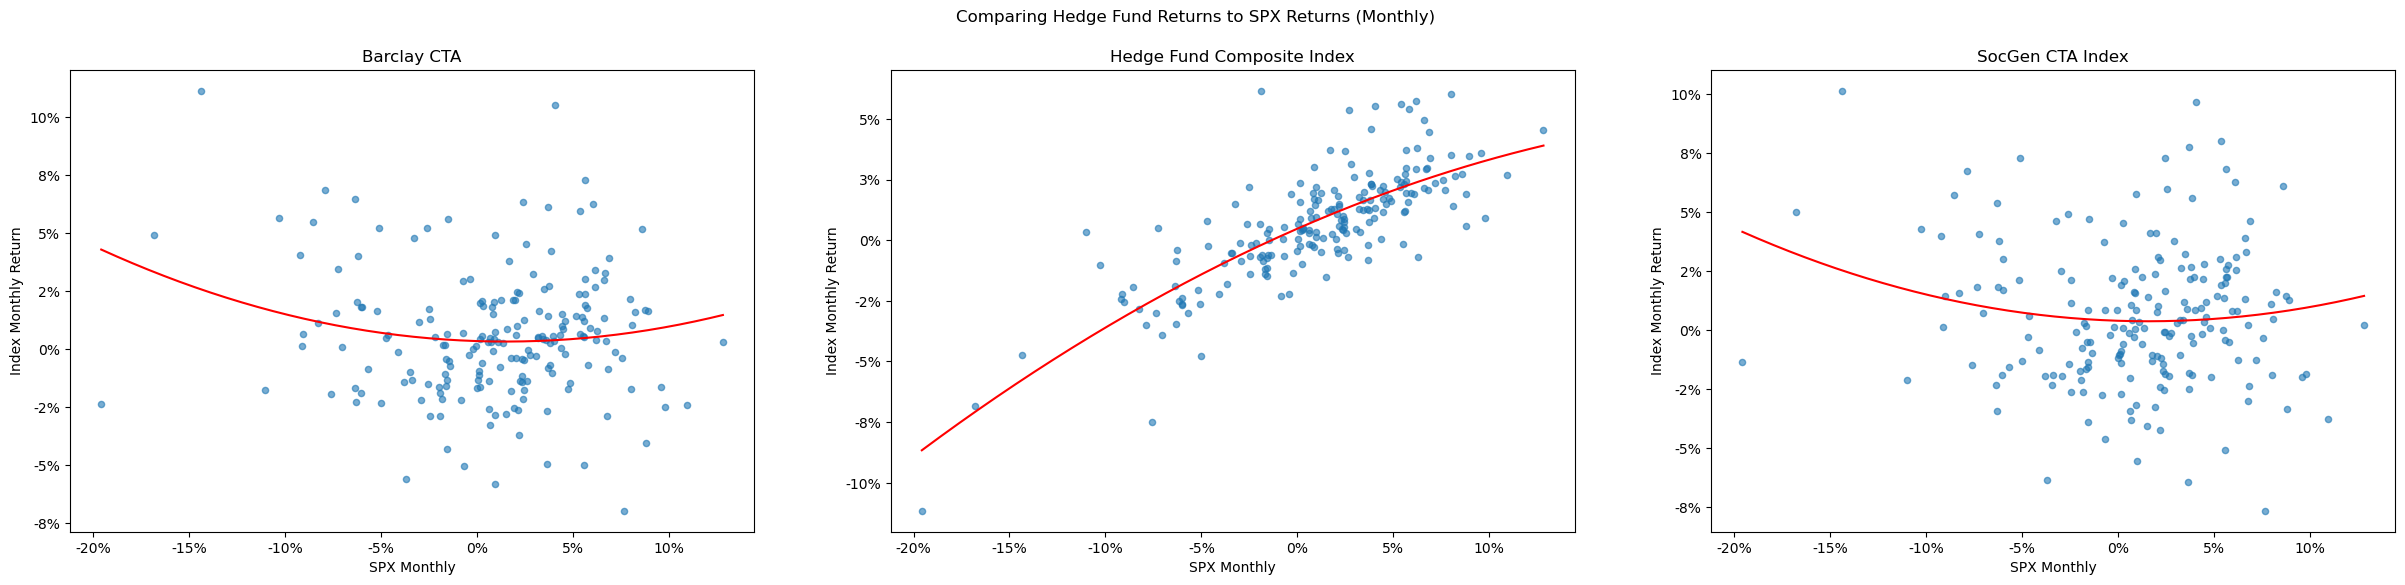

In [7]:
df_longer = (
    df_wider.reset_index()
    .melt(id_vars=["date", "SPX"])
)

variables = df_longer.variable.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols=len(variables), figsize=(30, 6))

df_poly_stats = pd.DataFrame()

for variable, ax in zip(variables, axes.flatten()):

    df_tmp = df_longer.query("variable == @variable")

    X = sm.add_constant(
        pd.DataFrame({
            "SPX": df_tmp.SPX,
            "SPX2": df_tmp.SPX**2
        })
    )

    model = sm.OLS(
        endog=df_tmp.value,
        exog=X
    ).fit()

    x = np.linspace(
        start=df_tmp.SPX.min(),
        stop=df_tmp.SPX.max(),
        num=200
    )

    X_plot = sm.add_constant(
        pd.DataFrame({
            "SPX": x,
            "SPX2": x**2
        })
    )

    y = model.predict(X_plot)

    (
        df_tmp.plot(
            alpha=0.6,
            kind="scatter",
            x="SPX",
            y="value",
            ax=ax,
            title=renamer[variable],
            ylabel="Index Monthly Return",
            xlabel="SPX Monthly",
        )
    )

    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
    ax.plot(x, y, color="red")

    df_poly_stats = pd.concat([
        df_poly_stats,
        model.params.rename("param")
        .to_frame()
        .assign(
            t_stat=model.tvalues,
            p_value=model.pvalues,
            r2=model.rsquared,
            variable=variable
        )
        .reset_index(names="term")
    ], ignore_index=True)

fig.suptitle("Comparing Hedge Fund Returns to SPX Returns (Monthly)")
plt.show()

In [8]:
(df_poly_stats[
    ["variable", "term", "r2", "param", "t_stat", "p_value"]].
    rename(columns = {
        "variable": "HF Index",
        "term"    : "Param Name",
        "r2"      : r"$R^2$",
        "param"   : "Param. Val",
        "t_stat"  : r"$t$-stat",
        "p_value" : r"$p$-value"}).
    replace({
        "const": r"$\alpha$",
        "SPX2" : r"SPX$^2$"}))

,HF Index,Param Name,$R^2$,Param. Val,$t$-stat,$p$-value
0,BARCBTOP,$\alpha$,0.026353,0.003471,1.457738,1.465213e-01
1,BARCBTOP,SPX,0.026353,-0.026842,-0.673597,5.013655e-01
2,BARCBTOP,SPX$^2$,0.026353,0.892945,1.928353,5.526357e-02
3,HFRIFWI,$\alpha$,0.619056,0.004749,3.736018,2.454514e-04
4,HFRIFWI,SPX,0.619056,0.346168,16.270571,3.620904e-38
5,HFRIFWI,SPX$^2$,0.619056,-0.616885,-2.495182,1.341943e-02
6,NEIXCTA,$\alpha$,0.020668,0.003964,1.538982,1.254298e-01
7,NEIXCTA,SPX,0.020668,-0.026519,-0.615107,5.392013e-01
8,NEIXCTA,SPX$^2$,0.020668,0.847225,1.691103,9.241481e-02


We find low $R^2$ values which are reported in similar fashion with the researchers. We are also interested in the loading factors of our regression. Its noticeable that CTA returns have low loadings to market factors and positive loading to squared market returns while it is the opposite case for the Hedge Fund return index. 

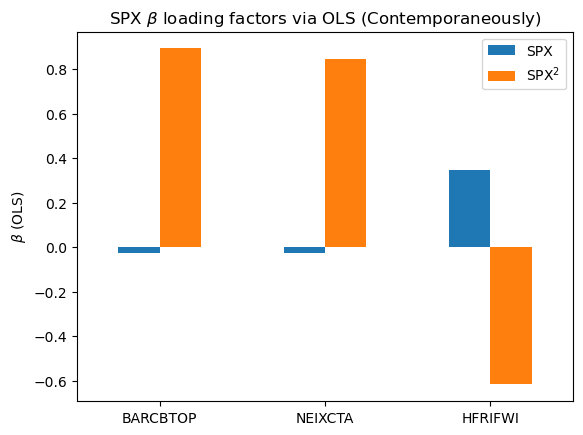

In [9]:
(df_poly_stats.query(
    "term != 'const'").
    rename(columns = {"term": ""}).
    pivot(index = "variable", columns = "", values = "param").
    sort_values(["SPX", "SPX2"]).
    rename(columns = {"SPX2": r"SPX$^2$"}).
    plot(
        kind = "bar",
        ylabel = r"$\beta$ (OLS)",
        rot    = 0,
        title  = r"SPX $\beta$ loading factors via OLS (Contemporaneously)",
        xlabel = ""))

plt.show()

# Volatility on different time scales: the signature plot

Using the authors' approach for computing $\sigma^2(\tau)$ via 
\begin{align}
\sigma^2(\tau) &= \frac{1}{\tau} \langle S_{t+\tau} - S_t  \rangle^2\\
&= \sigma^2 \frac{2}{\tau} \sum_{u=1}^\tau (\tau-u) C(u)
\end{align}

In [10]:
def autocovariance(r: pd.Series,
                   max_lag: int = 200) -> pd.Series:
    """
    Sample autocovariance function.

    Parameters
    ----------
    r : pd.Series
        Return (or price change) series.
    max_lag : int
        Maximum lag.

    Returns
    -------
    pd.Series
        Autocovariance indexed by lag.
    """

    r = r.dropna().astype(float)
    r = r - r.mean()

    C = {}

    x = r.to_numpy()

    for lag in range(max_lag + 1):

        if lag == 0:

            C[lag] = np.mean(x**2)

        else:

            C[lag] = np.mean(
                x[:-lag] * x[lag:]
            )

    return pd.Series(C)


def signature_volatility(r: pd.Series,
                         max_tau: int = 100) -> pd.DataFrame:
    """
    Compute the signature plot from Dao et al. (2016).

    Returns:

        sigma²(tau) / sigma²(1)

    where:

        sigma²(tau)
        =
        sigma²(1)
        +
        (2/tau)
        * Σ_{u=1}^{tau-1} (tau-u) C(u)

    Parameters
    ----------
    r : pd.Series
        Return series.

    max_tau : int
        Maximum aggregation horizon.

    Returns
    -------
    pd.DataFrame
        Columns:
            tau
            variance
            signature
    """

    C = autocovariance(r, max_tau)

    variance_1 = C.iloc[0]

    out = []

    for tau in range(1, max_tau + 1):

        if tau == 1:
            variance_tau = variance_1

        else:
            u = np.arange(1, tau)

            cov_sum = np.sum(
                (tau - u) * C.iloc[u].values
            )

            variance_tau = (
                variance_1
                + (2 / tau) * cov_sum
            )

        out.append({
            "tau": tau,
            "variance": variance_tau,
            "signature": variance_tau / variance_1
        })

    return pd.DataFrame(out)

In [11]:
ticker_path = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\TickerGuide.xlsx"

asset_class_mapper = (pd.read_excel(
    io = ticker_path, sheet_name = "fut_guide")
    [["Front", "group"]].
    assign(ticker = lambda x: x.Front.str.replace(" 1", "1").str.lower().str.replace(" ", "_")).
    drop_duplicates().
    set_index("ticker").
    group.
    to_dict())

In [12]:
def _get_signature_plot(df: pd.DataFrame) -> pd.DataFrame: 

    input_val = df.R
    df_out    = signature_volatility(input_val)
    return df_out

df_signature = (df_signal_raw.dropna().set_index(
    "date").
    groupby("ticker").
    apply(_get_signature_plot).
    reset_index().
    drop(columns = ["level_1"]).
    assign(asset_class = lambda x: x.ticker.map(asset_class_mapper)))

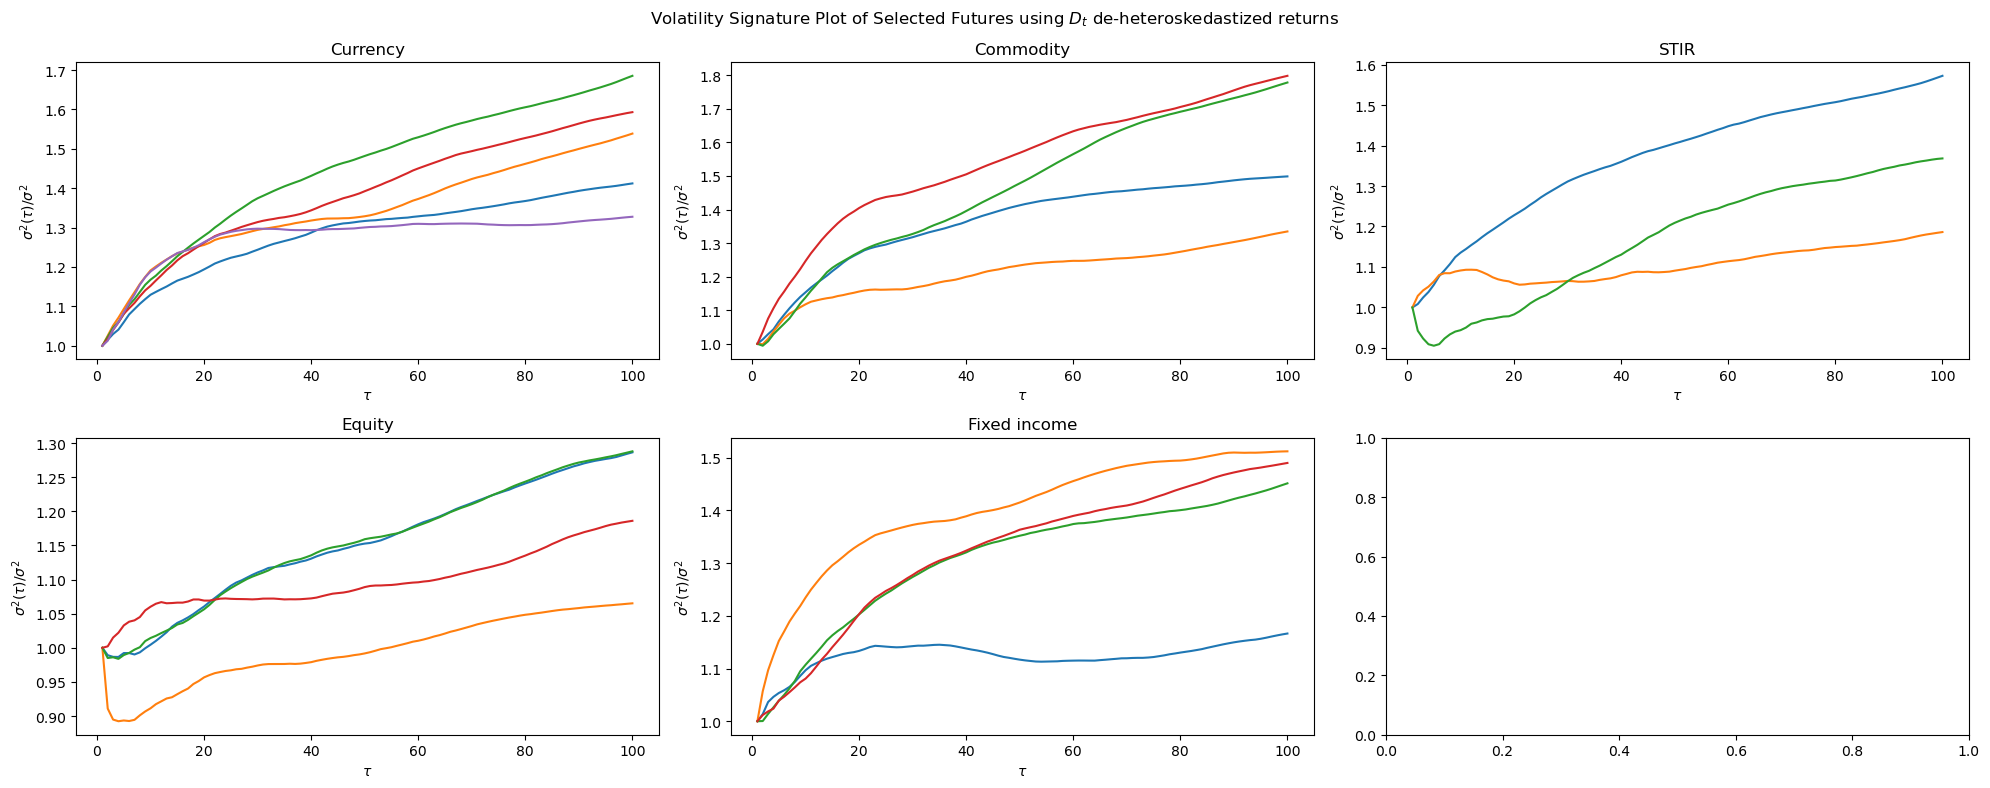

In [13]:
asset_classes = df_signature.asset_class.drop_duplicates().to_list()
fig, axes     = plt.subplots(ncols = 3, nrows = 2, figsize = (20,8))

for asset_class, ax in zip(asset_classes, axes.flatten()): 

    (df_signature.query(
        "asset_class == @asset_class").
        pivot(index = "tau", columns = "ticker", values = "signature").
        plot(
            ax     = ax,
            legend = False,
            xlabel = r"$\tau$",
            ylabel = r"$\sigma^2(\tau)/ \sigma^2$",
            title  = asset_class.replace("_", " ").capitalize().replace("Stir", "STIR")))

fig.suptitle("Volatility Signature Plot of Selected Futures using $D_t$ de-heteroskedastized returns")
plt.tight_layout()

Using the selected futures, we construct the volatility signature plot, which measures the relationship between volatility at longer horizons relative to volatility at shorter horizons. Rather than using raw returns $r_t$, we follow the authors and use $D_t$, the de-heteroskedasticized return series, which normalizes returns by a local volatility estimate. This adjustment removes time-varying volatility effects and allows the signature plot to capture the impact of return autocorrelation across different time scales. In this case $D_t$ is expressed as 
\begin{equation}
\frac{D_t}{\gamma \sqrt{\mathcal{L}_{\tau_\sigma}[D_t^2]}}
\end{equation}
The author sets $\tau_{\sigma} = 10$ which is used as well. 

# Examining the Convexity of Trend Returns

Before examining the strategy returns, we first inspect the trend signal. At the beginning of each time series, the signal can exhibit unusually large values due to the initialization of the recursive EWMA calculation, where the volatility estimate has not yet fully stabilized. To mitigate this initialization effect, we exclude the early portion of each signal from the analysis.

In [30]:
def clean_signal(
    df_signal: pd.DataFrame,
    bad_cols : list = ["jb1_comdty", "nk1_index", "sf1_curncy"]) -> pd.DataFrame:

    df_lists = []
    for ticker in tmp_tickers: 
    
        df_add = (df_signal.query(
            "ticker == @ticker").
            assign(year = lambda x: pd.to_datetime(x.date).dt.year).
            query("year != year.min()").
            drop(columns = ["year"]))
    
        if ticker in bad_cols:
    
            df_add = (df_add.assign(
                year = lambda x: pd.to_datetime(x.date).dt.year).
                query("year != year.min()").
                drop(columns = ["year"]))
            
        df_lists.append(df_add)

    df_out = (pd.concat(df_lists))
    return df_out

In [31]:
df_signal_prep = clean_signal(df_signal_raw)

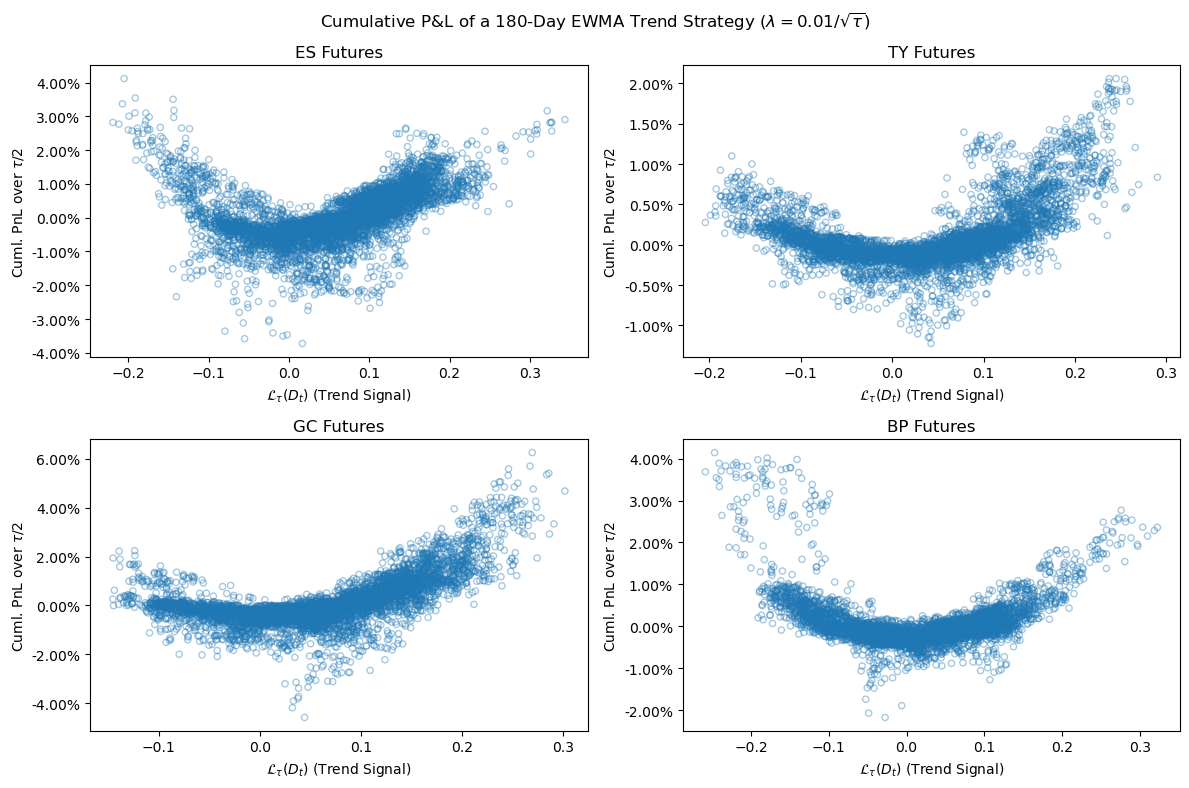

In [34]:
sample_asset_classes = {
    "Equity"      : "es1_index",
    "Fixed Income": "ty1_comdty",
    "Commodity"   : "gc1_comdty",
    "Currency"    : "bp1_curncy"}

keys      = sample_asset_classes.keys()
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (12,8))

for asset_class, ax in zip(keys, axes.flatten()): 

    tmp = sample_asset_classes[asset_class]
    
    df_perf = (df_signal_prep.dropna().query(
        "ticker == @tmp").
        sort_values("date").
        assign(cuml_rtn = lambda x: x.signal_rtn.rolling(window = 90).sum()))

    ax.scatter(
        x          = df_perf.lag_signal,
        y          = df_perf.cuml_rtn,
        facecolor  = "none",
        alpha      = 0.4,
        edgecolors = "tab:blue",
        s          = 20)

    ax.set_ylabel(r"Cuml. PnL over $\tau$/2")
    ax.set_xlabel(r"$\mathcal{L}_{\tau}(D_t)$ (Trend Signal)")
    ax.set_title(tmp.split("1")[0].upper() + " Futures")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2%}"))

fig.suptitle(
    r"Cumulative P&L of a 180-Day EWMA Trend Strategy ($\lambda=0.01/\sqrt{\tau}$)")
plt.tight_layout()

The payoff profile closely matches the expected behavior of a trend-following strategy, exhibiting a positive convex relationship between underlying returns and strategy returns. The resulting shape is also consistent with the empirical findings presented in the paper. One important consideration is that the returns generated within the codebase are affected by a scaling difference, resulting in smaller observed P&L values. This primarily arises from the volatility targeting framework, which produces smaller portfolio weights. However, this scaling effect is not economically meaningful, as the strategy can be rescaled by a constant factor (ignoring financing considerations).

Additionally, volatility targeting introduced some instability due to limited observations at the beginning of the sample. Since the volatility estimate is computed using an exponential weighting scheme, the initial estimates can be unreliable, leading to improper position sizing. To address this initialization effect, the first 100 observations are excluded from the analysis.

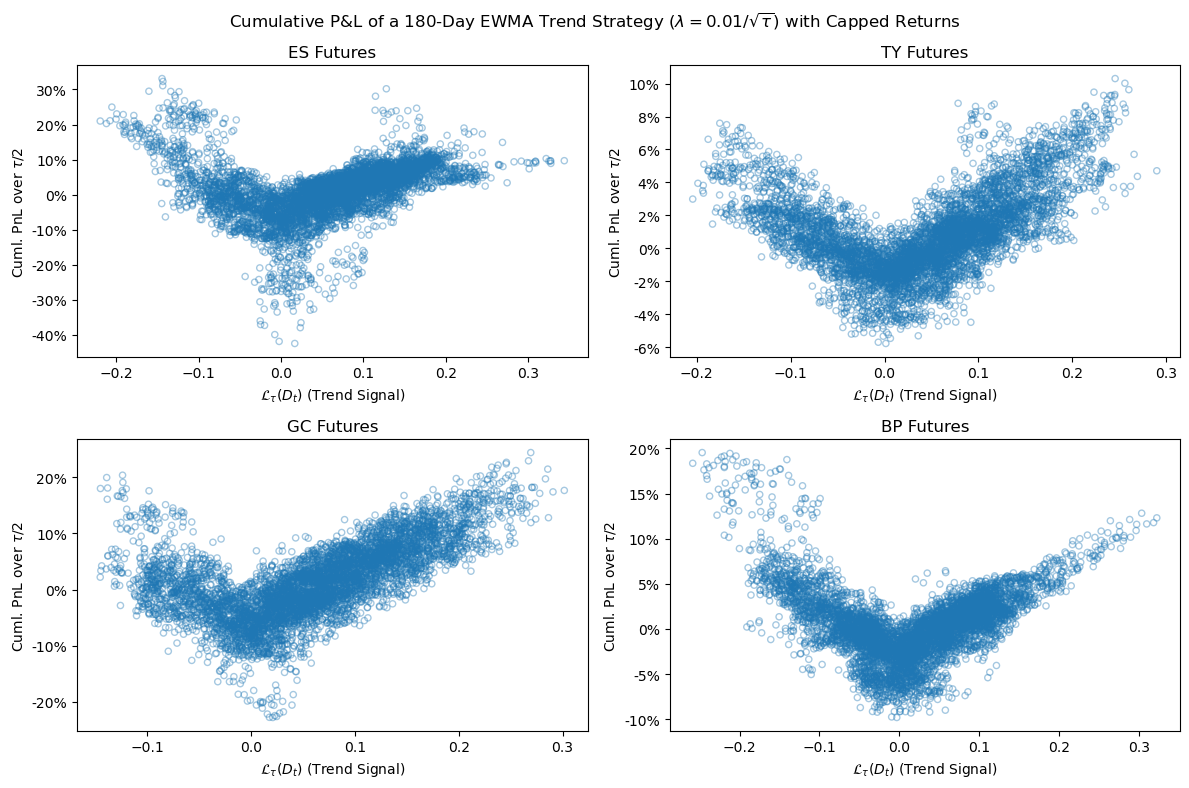

In [35]:
keys      = sample_asset_classes.keys()
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (12,8))

for asset_class, ax in zip(keys, axes.flatten()): 

    tmp = sample_asset_classes[asset_class]
    lam = 0.01 / np.sqrt(180)
    
    df_perf = (df_signal_prep.dropna().query(
        "ticker == @tmp").
        sort_values("date").
        assign(
            signal_rtn = lambda x: np.sign(x.lag_signal) * lam * x.px_rtn,
            cuml_rtn   = lambda x: x.signal_rtn.rolling(window = 90).sum()))

    ax.scatter(
        x          = df_perf.lag_signal,
        y          = df_perf.cuml_rtn,
        facecolor  = "none",
        alpha      = 0.4,
        edgecolors = "tab:blue",
        s          = 20)

    ax.set_ylabel(r"Cuml. PnL over $\tau$/2")
    ax.set_xlabel(r"$\mathcal{L}_{\tau}(D_t)$ (Trend Signal)")
    ax.set_title(tmp.split("1")[0].upper() + " Futures")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*10_00:.0%}"))

fig.suptitle(
    r"Cumulative P&L of a 180-Day EWMA Trend Strategy ($\lambda=0.01/\sqrt{\tau}$) with Capped Returns")
plt.tight_layout()

# Replicating SocGen CTA Index

In [18]:
df_scaled_port = (df_signal_prep[
    ["date", "ticker", "signal_rtn", "lag_weight", "weight"]].
    melt(id_vars = ["date", "ticker", "signal_rtn"]).
    assign(
        date         = lambda x: pd.to_datetime(x.date),
        weighted_rtn = lambda x: x.signal_rtn * x.value)
    [["date", "variable", "weighted_rtn"]].
    groupby(["date", "variable"]).
    agg("mean").
    reset_index())

In [36]:
def get_binary_signal(
    df        : pd.DataFrame,
    lags      : list = [0, 1],
    vol_target: float = 0.01,
    window    : int   = 100) -> pd.DataFrame: 

    df_lists = []
    for lag in lags: 
    
        df_tmp = (df.assign(
            signal_rtn = lambda x: np.sign(x.lag_signal) * x.px_rtn).
            pivot(index = "date", columns = "ticker", values = "signal_rtn").
            apply(lambda x: x * (vol_target / (x.ewm(span = window, adjust = False).std().shift(lag)))).
            apply(lambda x: np.where(np.abs(x) > 0.1, np.nan, x)).
            mean(axis = 1).
            to_frame(name = "port").
            assign(lag = lag))
    
        df_lists.append(df_tmp)
    
    df_out = pd.concat(df_lists)
    return df_out

df_binary_port = (get_binary_signal(
    df_signal_prep).
    reset_index().
    assign(date = lambda x: pd.to_datetime(x.date)).
    pivot(index = "date", columns = "lag", values = "port").
    rename(columns = {0: "lag_weight", 1: "weight"}))

In [37]:
df_sg = (df_hf.query(
    "security == 'NEIXCTA Index'").
    set_index("date")
    [["PX_LAST"]].
    rename(columns = {"PX_LAST": "sg"}).
    pct_change().
    dropna())

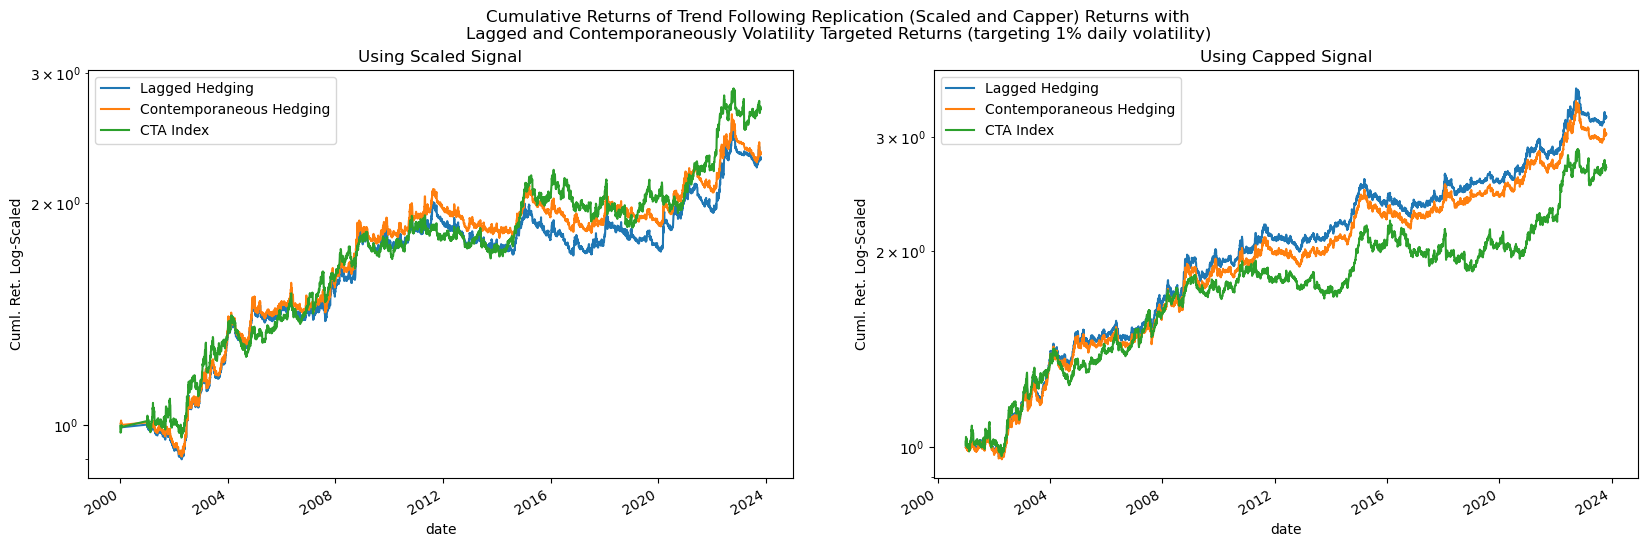

In [38]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

renamer = {
    "lag_weight": "Lagged Hedging",
    "weight"    : "Contemporaneous Hedging",
    "sg"        : "CTA Index"}

(df_scaled_port.pivot(
    index = "date", columns = "variable", values = "weighted_rtn").
    merge(right = df_sg, how = "inner", on = ["date"]).
    apply(lambda x: np.cumprod(1 + x)).
    rename(columns = renamer).
    plot(
        ax     = axes[0],
        logy   = True,
        title  = "Using Scaled Signal",
        ylabel = "Cuml. Ret. Log-Scaled"))

(df_binary_port.merge(
    right = df_sg, how = "inner", on = ["date"]).
    apply(lambda x: np.cumprod(1 + x)).
    rename(columns = renamer).
    plot(
        logy   = True,
        ax     = axes[1],
        title  = "Using Capped Signal",
        ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Cumulative Returns of Trend Following Replication (Scaled and Capper) Returns with\nLagged and Contemporaneously Volatility Targeted Returns (targeting 1% daily volatility)")
plt.show()

In [39]:
df_wider = (df_scaled_port.assign(
    variable = lambda x: "scaled" + np.where(x.variable == "weight", "_perf", "_lag")).
    pivot(index = "date", columns = "variable", values = "weighted_rtn").
    merge(right = df_binary_port, how = "inner", on = ["date"]).
    rename(columns = {
        "lag_weight": "binary_lag",
        "weight"    : "binary_perf"}).
    dropna().
    merge(right = df_sg, how = "inner", on = ["date"]))

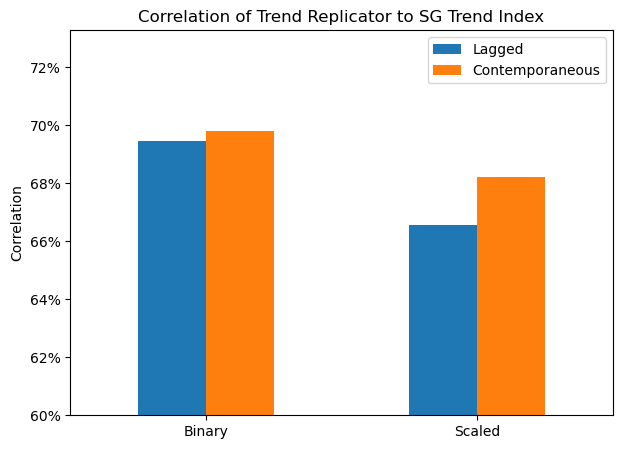

In [40]:
fig, axes = plt.subplots(figsize = (7,5))

(df_wider.reset_index().melt(
    id_vars = ["date", "sg"]).
    drop(columns = ["date"]).
    groupby("variable").
    agg("corr").
    query("value != 1").
    reset_index().
    assign(
        signal = lambda x: x.variable.str.split("_").str[0],
        lag    = lambda x: x.variable.str.split("_").str[1]).
    rename(columns = {"lag": ""}).
    replace({
        "binary": "Binary",
        "scaled": "Scaled"}).
    pivot(index = "signal", columns = "", values = "value").
    rename(columns = {
        "lag" : "Lagged",
        "perf": "Contemporaneous"}).
    plot(
        ax     = axes,
        kind   = "bar",
        ylim   = 0.6,
        rot    = 0,
        xlabel = "",
        ylabel = "Correlation",
        title  = "Correlation of Trend Replicator to SG Trend Index"))

axes.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.show()

In [41]:
df_cuml = (df_wider.apply(
    lambda x: x.rolling(window = 90).sum()).
    reset_index().
    melt(id_vars = "date", value_name = "trend_rtn").
    dropna().
    assign(date = lambda x: pd.to_datetime(x.date).dt.date))

In [42]:
df_combined = (df_signal_prep.query(
    "ticker == 'es1_index'")
    [["date", "signal"]].
    merge(right = df_cuml, how = "inner", on = ["date"]).
    assign(signal = lambda x: np.sqrt(90) * x.signal))

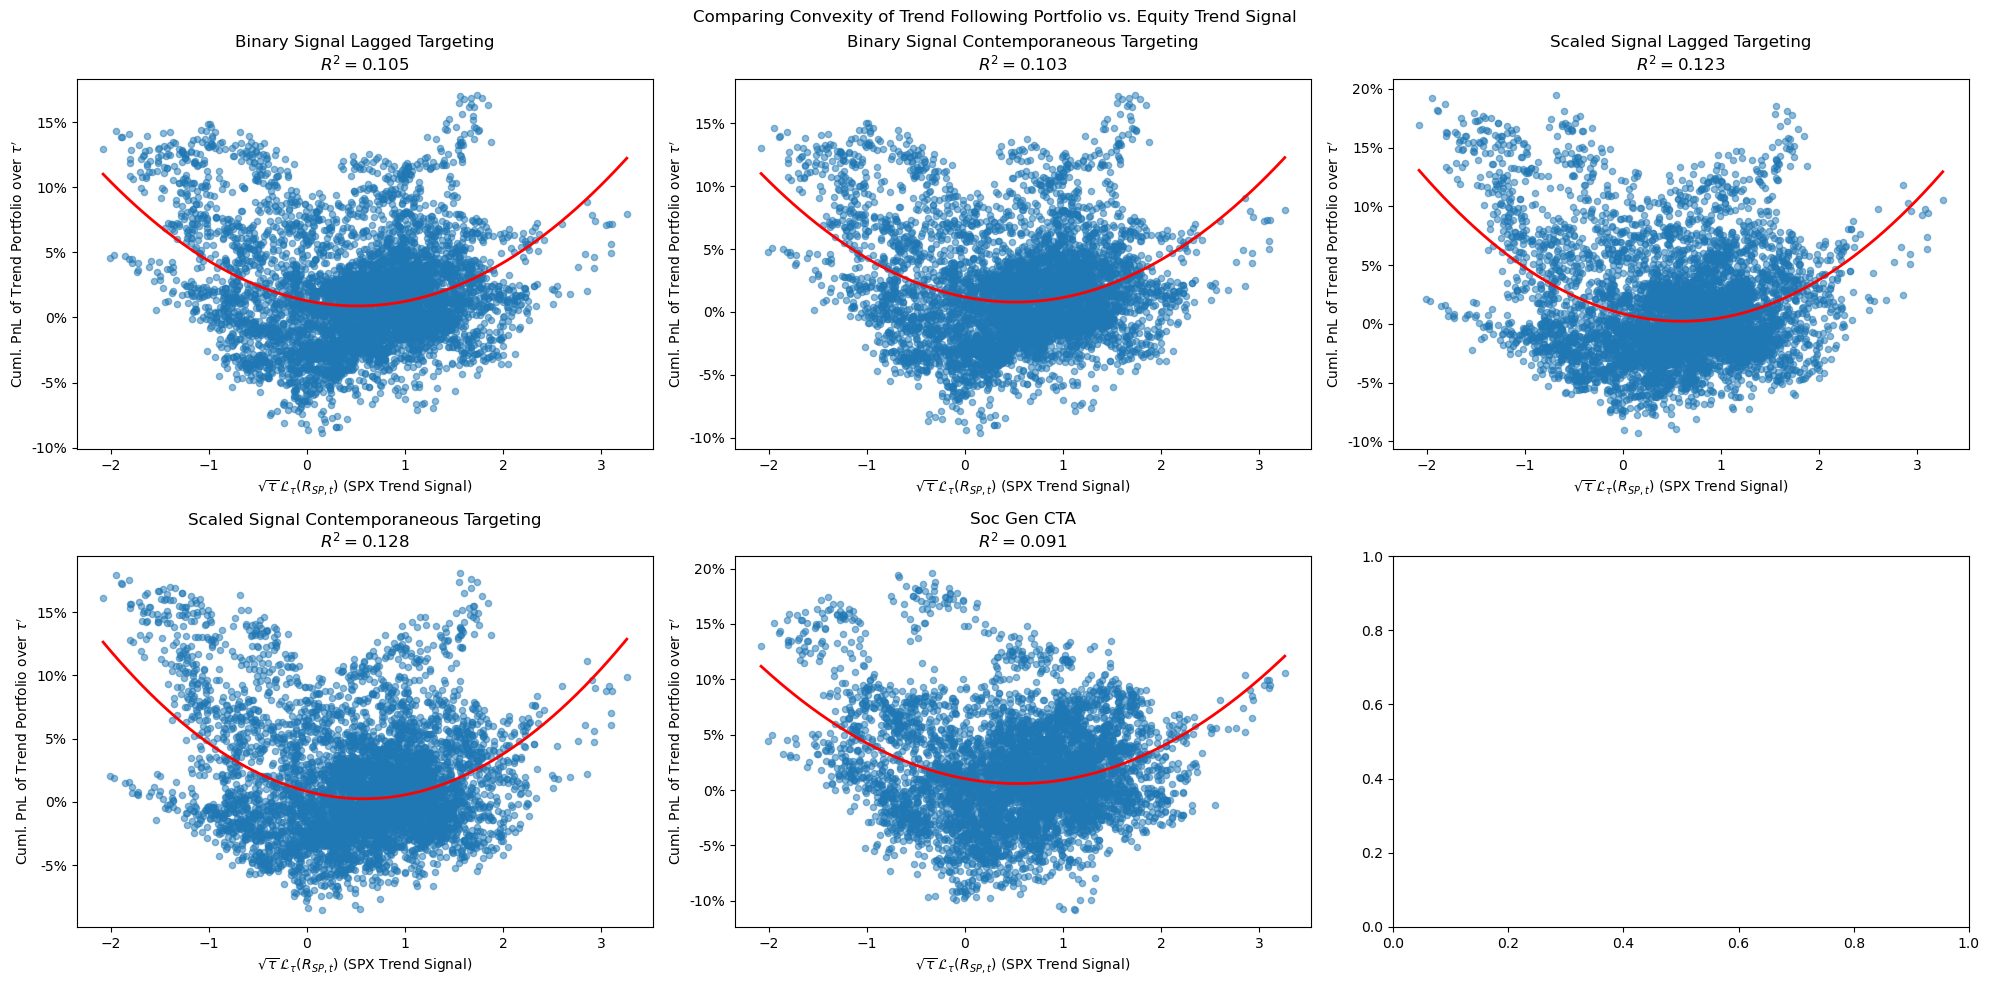

In [45]:
variables = df_combined.variable.drop_duplicates().sort_values().to_list()

fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(20, 10))

signal_mapper = {
    "binary": "Binary Signal",
    "scaled": "Scaled Signal"
}

lag_mapper = {
    "lag": "Lagged Targeting",
    "perf": "Contemporaneous Targeting"
}

for variable, ax in zip(variables, axes.flatten()):

    df_tmp = (
        df_combined
        .query("variable == @variable")
        .dropna(subset=["signal", "trend_rtn"])
    )

    if variable == "sg":
        title = "Soc Gen CTA"
    else:
        signal, lag = variable.split("_")
        title = signal_mapper[signal] + " " + lag_mapper[lag]

    df_tmp.plot(
        ax=ax,
        kind="scatter",
        x="signal",
        y="trend_rtn",
        alpha=0.5,
        ylabel=r"Cuml. PnL of Trend Portfolio over $\tau'$",
        xlabel=r"$\sqrt{\tau}\,\mathcal{L}_{\tau}(R_{SP,t})$ (SPX Trend Signal)"
    )

    # Quadratic fit
    x = df_tmp["signal"].to_numpy()
    y = df_tmp["trend_rtn"].to_numpy()

    coef = np.polyfit(x, y, deg=2)
    poly = np.poly1d(coef)

    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = poly(x_fit)

    ax.plot(
        x_fit,
        y_fit,
        color="red",
        lw=2,
        label="Quadratic Fit"
    )

    # R²
    y_hat = poly(x)
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    ax.set_title(f"{title}\n$R^2={r2:.3f}$")

    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{x:.0%}")
    )

fig.suptitle("Comparing Convexity of Trend Following Portfolio vs. Equity Trend Signal")
plt.tight_layout()